In [5]:
# Reproducible setup and output folders.
from pathlib import Path
import json
import random
from datetime import datetime

import numpy as np

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

PROJECT_ROOT = Path('.')
MODELS_DIR = PROJECT_ROOT / 'models'
METRICS_DIR = PROJECT_ROOT / 'metrics'
MLRUNS_DIR = PROJECT_ROOT / 'mlruns'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MLRUNS_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# Core ML and tracking imports.
import mlflow
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import dump
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Helper for timestamped artifact names.
def now_ts() -> str:
    return datetime.now().strftime('%Y%m%d%H%M%S')

def pretty_print_metrics(metrics: dict) -> None:
    print(json.dumps(metrics, indent=2))

In [7]:
# Load and inspect lab dataset.
dataset = load_breast_cancer()
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Class distribution: {y.value_counts().to_dict()}')
X.head(3)

X shape: (569, 30)
y shape: (569,)
Class distribution: {1: 357, 0: 212}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


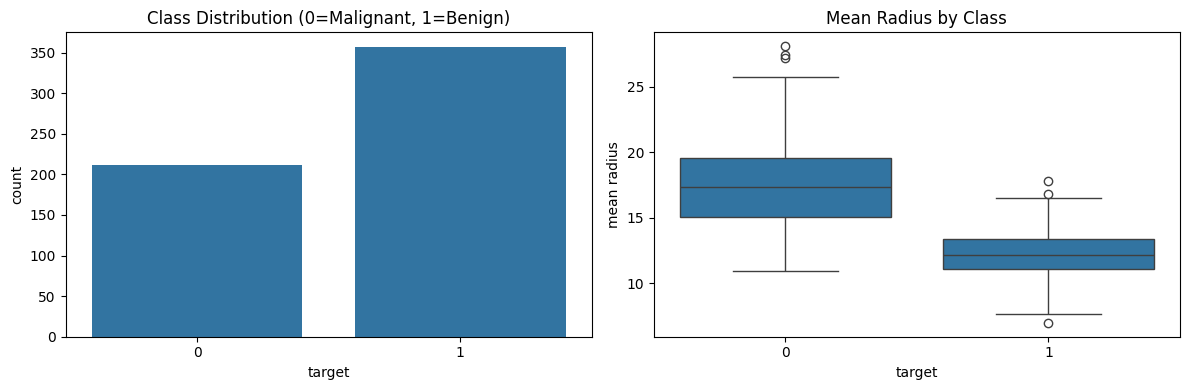

In [8]:
# Class balance and feature distribution snapshot.
plot_df = X.copy()
plot_df['target'] = y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='target', data=plot_df, ax=axes[0])
axes[0].set_title('Class Distribution (0=Malignant, 1=Benign)')

sns.boxplot(x='target', y='mean radius', data=plot_df, ax=axes[1])
axes[1].set_title('Mean Radius by Class')

plt.tight_layout()
plt.show()

In [9]:
# Quick EDA summary.
data = X.copy()
data['target'] = y

print(data['target'].value_counts().rename(index={0: 'malignant', 1: 'benign'}))
print('\nMissing values per column (non-zero only):')
print(data.isna().sum()[data.isna().sum() > 0])

data.describe().T.head(10)

target
benign       357
malignant    212
Name: count, dtype: int64

Missing values per column (non-zero only):
Series([], dtype: int64)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [10]:
# Split helper.
def split_data(features: pd.DataFrame, target: pd.Series):
    return train_test_split(
        features,
        target,
        test_size=0.2,
        random_state=SEED,
        stratify=target,
    )

# Model factory.
def build_model() -> XGBClassifier:
    return XGBClassifier(
        n_estimators=100,
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0,
    )

# Metric helper.
def evaluate_model(model, x_test, y_test) -> dict:
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:, 1]
    return {
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'f1': float(f1_score(y_test, y_pred)),
        'roc_auc': float(roc_auc_score(y_test, y_pred_proba)),
    }

In [11]:
# Train model and compute metrics.
X_train, X_test, y_train, y_test = split_data(X, y)
model = build_model()
model.fit(X_train, y_train)
metrics = evaluate_model(model, X_test, y_test)
pretty_print_metrics(metrics)

{
  "accuracy": 0.956140350877193,
  "f1": 0.9659863945578231,
  "roc_auc": 0.9900793650793651
}


In [12]:
# Extra evaluation artifacts.
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['malignant', 'benign']))

feature_importances = (
    pd.DataFrame({'feature': X_train.columns, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=False)
)
feature_importance_csv = METRICS_DIR / 'feature_importance_latest.csv'
feature_importances.to_csv(feature_importance_csv, index=False)
feature_importances.head(10)

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



,feature,importance
20,worst radius,0.585115
22,worst perimeter,0.165952
27,worst concave points,0.052235
7,mean concave points,0.035588
11,texture error,0.031616
25,worst compactness,0.018118
23,worst area,0.017973
21,worst texture,0.014540
10,radius error,0.011736
12,perimeter error,0.010272


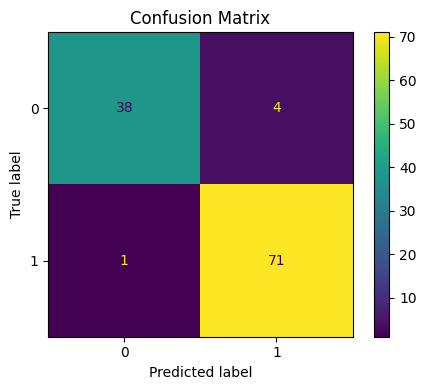

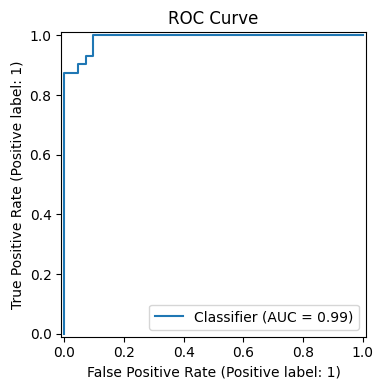

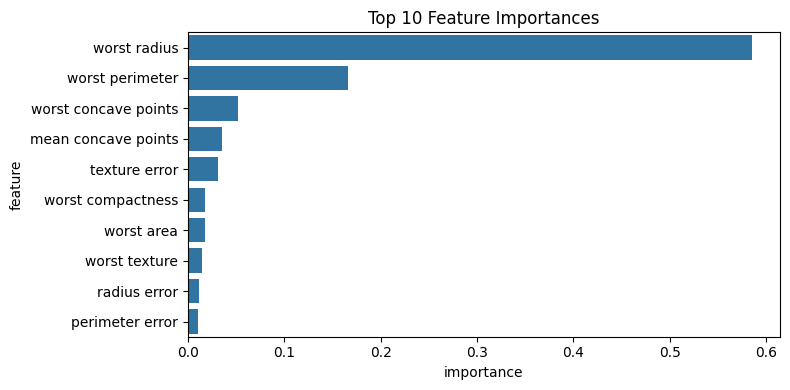

In [13]:
# Confusion matrix, ROC, and feature-importance chart.
cm_path = METRICS_DIR / 'confusion_matrix_latest.png'
roc_path = METRICS_DIR / 'roc_curve_latest.png'
fi_plot_path = METRICS_DIR / 'feature_importance_latest.png'

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title('Confusion Matrix')
fig.tight_layout()
fig.savefig(cm_path, dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title('ROC Curve')
fig.tight_layout()
fig.savefig(roc_path, dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=feature_importances.head(10), x='importance', y='feature', ax=ax)
ax.set_title('Top 10 Feature Importances')
fig.tight_layout()
fig.savefig(fi_plot_path, dpi=150)
plt.show()

In [14]:
# Basic sanity checks.
required_keys = {'accuracy', 'f1', 'roc_auc'}
assert required_keys.issubset(set(metrics.keys()))
assert 0.0 <= metrics['accuracy'] <= 1.0
assert 0.0 <= metrics['f1'] <= 1.0
assert 0.0 <= metrics['roc_auc'] <= 1.0
print('Validation checks passed.')

Validation checks passed.


In [15]:
# Inspect a few predictions.
sample = X_test.head(5)
sample_preds = model.predict(sample)
pd.DataFrame({'prediction': sample_preds}, index=sample.index)

,prediction
256,0
428,1
501,0
363,0
564,0


In [16]:
# Save artifacts and log run to MLflow.
timestamp = now_ts()
model_path = MODELS_DIR / f'model_{timestamp}_xgb_model.joblib'
metrics_path = METRICS_DIR / f'{timestamp}_metrics.json'

dump(model, model_path)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

mlflow.set_tracking_uri(str(MLRUNS_DIR))
mlflow.set_experiment('Breast_Cancer_XGBoost')
with mlflow.start_run(run_name=f'notebook_train_{timestamp}'):
    mlflow.log_params({
        'dataset': 'breast_cancer',
        'n_samples': int(X.shape[0]),
        'n_features': int(X.shape[1]),
        'model': 'XGBClassifier',
        'test_size': 0.2,
        'random_state': SEED,
        'n_estimators': 100,
    })
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(model, name='model')
    mlflow.log_artifact(str(model_path), artifact_path='local_models')
    mlflow.log_artifact(str(metrics_path), artifact_path='local_metrics')

    if 'feature_importance_csv' in globals() and feature_importance_csv.exists():
        mlflow.log_artifact(str(feature_importance_csv), artifact_path='analysis')
    for p in [globals().get('cm_path'), globals().get('roc_path'), globals().get('fi_plot_path')]:
        if p is not None and p.exists():
            mlflow.log_artifact(str(p), artifact_path='analysis')

print(f'Model saved to: {model_path}')
print(f'Metrics saved to: {metrics_path}')
print('MLflow run logged successfully.')

e:\NEU Stuff\IE7374\MLOPs\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/03/14 03:02:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved to: models\model_20260314030227_xgb_model.joblib
Metrics saved to: metrics\20260314030227_metrics.json
MLflow run logged successfully.


In [21]:
# mlflow models serve --env-manager=local -m models:/Breast_Cancer_XGBoost@latest -h 0.0.0.0 -p 5001

import requests

payload = {'dataframe_split': X_test.head(10).to_dict(orient='split')}
try:
    response = requests.post('http://localhost:5001/invocations', json=payload, timeout=10)
    print(response.status_code)
    print(response.json())
except Exception as ex:
    print(f'Serving endpoint not reachable yet: {ex}')

200
{'predictions': [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]}
